In [100]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

In [101]:
# Organize the excel file in a dataframe
df = pd.read_excel("Concrete_Data.xls")

# Seperate the target variable (Concrete compressive strength) from the rest "predicting" attributes
X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '], axis=1)
# Target variable
y= df['Concrete compressive strength(MPa, megapascals) '].values

# Split data in training and test tests
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # I found 18% for test set returns the lowest RMSE
 
# Standardize features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

# Implement linear regression fitting the training data
linreg = LinearRegression() # Model initialized with no learn coefficients yet
linreg.fit(X_train_std, y_train) # Model is being trained

w = linreg.coef_
w0 = linreg.intercept_

print("Optimal Coefficients (w*):", w)
print("Intercept (w0):", w0)
print("\nMatrix equation: ŷ = Xw + w0")

equation = "ŷ = {:.3f}".format(w0)
for coef, name in zip(w, X.columns):
    equation += " + ({:.3f} × {})".format(coef, name)

print("\nLearned linear regression equation:\n", equation)

# Prediction values from the test data
y_pred = linreg.predict(X_test_std)

# Square Root of Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE :", rmse, "MPa")

Optimal Coefficients (w*): [12.78650432  9.43288328  5.25560873 -2.89208457  1.84110286  1.40025548
  1.94738031  7.037787  ]
Intercept (w0): 35.857718068042345

Matrix equation: ŷ = Xw + w0

Learned linear regression equation:
 ŷ = 35.858 + (12.787 × Cement (component 1)(kg in a m^3 mixture)) + (9.433 × Blast Furnace Slag (component 2)(kg in a m^3 mixture)) + (5.256 × Fly Ash (component 3)(kg in a m^3 mixture)) + (-2.892 × Water  (component 4)(kg in a m^3 mixture)) + (1.841 × Superplasticizer (component 5)(kg in a m^3 mixture)) + (1.400 × Coarse Aggregate  (component 6)(kg in a m^3 mixture)) + (1.947 × Fine Aggregate (component 7)(kg in a m^3 mixture)) + (7.038 × Age (day))
RMSE : 9.796707832398447 MPa


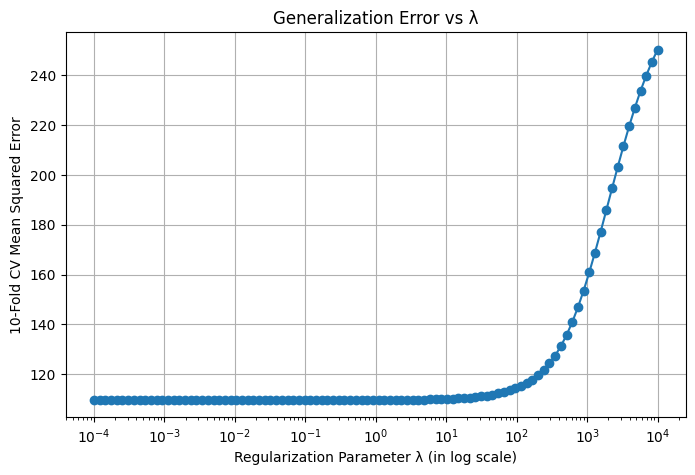

Optimal λ: 1.3219411484660315
Optimal Coefficients (w*): [12.28046644  8.72908503  5.42338152 -3.36256964  1.73881552  1.24443637
  1.41243462  7.19208592]
Intercept (w0): 35.8178358261136
Cement (component 1)(kg in a m^3 mixture) : 12.2805
Blast Furnace Slag (component 2)(kg in a m^3 mixture) : 8.7291
Fly Ash (component 3)(kg in a m^3 mixture) : 5.4234
Water  (component 4)(kg in a m^3 mixture) : -3.3626
Superplasticizer (component 5)(kg in a m^3 mixture) : 1.7388
Coarse Aggregate  (component 6)(kg in a m^3 mixture) : 1.2444
Fine Aggregate (component 7)(kg in a m^3 mixture) : 1.4124
Age (day)                 : 7.1921


In [102]:
X_scaled = scaler.fit_transform(X)

# λ values from 10^-4 to 10^4
lambdas = np.logspace(-4, 4, 100)  
tenfold = KFold(n_splits=10, shuffle=True, random_state=42)

mse_scores = []

for l in lambdas:
    ridge = Ridge(alpha=l)
    neg_mse = cross_val_score(ridge, X_scaled, y, cv=tenfold, scoring='neg_mean_squared_error')
    mse_scores.append(-neg_mse.mean())

plt.figure(figsize=(8,5))
plt.semilogx(lambdas, mse_scores, marker='o')
plt.xlabel("Regularization Parameter λ (in log scale)")
plt.ylabel("10-Fold CV Mean Squared Error")
plt.title("Generalization Error vs λ")
plt.grid(True)
plt.show()

optimal_lambda = lambdas[np.argmin(mse_scores)]
print("Optimal λ:", optimal_lambda)

ridge_final = Ridge(alpha=optimal_lambda)
ridge_final.fit(X_scaled, y)

w = ridge_final.coef_
w0 = ridge_final.intercept_
print("Optimal Coefficients (w*):", w)
print("Intercept (w0):", w0)

for name, value in zip(X.columns, w):
    print(f"{name:25s} : {value:.4f}")